In [360]:
import pandas as pd
import numpy as np
import pickle
import re
import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.metrics import classification_report
from nltk.tokenize import TreebankWordTokenizer
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('vader_lexicon')

import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lovet\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\lovet\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\lovet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Bring in the data

The URL data used as a starting point for training the LDA model originally came from repeated "latest news" calls via the NewsData.io API. Each API call resulted in 10 articles retrieved, and were stored as Pickles.

Later, a secondary function was used to scrape the content for the retrieved URLs, and that content was added to a dataframe. The dataframe was then exported to an excel sheet.

### Data Quality Checks
The models don't like it when something ain't right.

In [361]:
news_training_df = pd.read_excel('Datasets/scraped_news_articles.xlsx')
news_training_df.dtypes

Unnamed: 0               int64
Date            datetime64[us]
Source                     str
Title                      str
page_url                   str
scraped_text               str
dtype: object

In [362]:
print(f"Columns: {news_training_df.shape[1]}, Rows: {news_training_df.shape[0]}")
print(f"NaNs: {news_training_df.isna().any(axis=1).sum()}")
print(f"Full, exact duplicate matches: {news_training_df.duplicated().sum()}")
print(f"Duplicated content: {news_training_df['scraped_text'].duplicated().sum()}")
print(f"Duplicated URLs: {news_training_df['page_url'].duplicated().sum()}")

Columns: 6, Rows: 1235
NaNs: 475
Full, exact duplicate matches: 0
Duplicated content: 514
Duplicated URLs: 0


Tidy what needs tidyin'
- Duplicate rows
- Content that requires a subscription to access (ie. Herald Premium - it won't have scraped the actual article content, just a bunch of 'subsribe to premium' which is worthless for modelling)

In [363]:
print(f"Premium (Herald) URLs before removal: {news_training_df['page_url'].str.contains('/premium/').sum()}")
print(f"Premium (Business Desk) URLs before removal: {news_training_df['page_url'].str.startswith('https://businessdesk.co.nz/').sum()}")
print(f"Premium (NBR) URLs before removal: {news_training_df['page_url'].str.startswith('https://www.nbr.co.nz/').sum()}")

news_training_df = news_training_df[~news_training_df['page_url'].str.contains('/premium/')]
news_training_df = news_training_df[~news_training_df['page_url'].str.startswith('https://businessdesk.co.nz/')]
news_training_df = news_training_df[~news_training_df['page_url'].str.startswith('https://www.nbr.co.nz/')]

Premium (Herald) URLs before removal: 49
Premium (Business Desk) URLs before removal: 20
Premium (NBR) URLs before removal: 14


In [364]:
# Drop problematic rows
news_training_df.drop_duplicates(subset=['page_url'], keep='first', inplace=True)
news_training_df.drop_duplicates(subset=['scraped_text'], keep='first', inplace=True)
news_training_df.dropna(inplace=True)

print(f"Columns: {news_training_df.shape[1]}, Rows: {news_training_df.shape[0]}")
print(f"NaNs: {news_training_df.isna().any(axis=1).sum()}")
print(f"Duplicates: {news_training_df.duplicated().sum()}")
print(f"Duplicate URLs: {news_training_df['page_url'].duplicated().sum()}")

Columns: 6, Rows: 658
NaNs: 0
Duplicates: 0
Duplicate URLs: 0


# Topic Modelling: Latent Dirichlet Allocation (LDA)
### Preprocessing the data
The data needs to be run through a couple of processes before it's optimised for use with the LDA.

For the purposes of comparison: two LDA models, different preprocessing.

In [365]:
lemmatizer = WordNetLemmatizer()
tokenizer = TreebankWordTokenizer()

def preprocess_text(text):
    text = re.sub('\'\n', '', text)  # Remove apostrophes and newlines
    text = re.sub('[^a-zA-Z]', ' ', text)  # Remove non-alphabet characters
    text = text.lower()  # Convert to lowercase
    return text

# This function is for identifying/tagging different parts of speech in the text
def get_wordnet_pos(treebank_tag):
    # Function to map Treebank POS tags to WordNet POS tags
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Default to noun

# This function is for lemmatization (which improves when the parts of speech are tagged accordingly, 
# otherwise it defaults to treating everything as a Noun)
def lemmatize_tokenizer(text):   
    tokens = tokenizer.tokenize(str(text))
    # 3. Apply POS Tagging & Lemmatization
    lemmatized = [lemmatizer.lemmatize(token, get_wordnet_pos(tag)) 
                  for token, tag in nltk.pos_tag(tokens)]
    return " ".join(lemmatized)

### Preprocessing using NLTK's WordNetLemmatizer and TreebankWordTokenizer

In [366]:
# Preprocessing and lemmatizing
news_training_df['Content'] = news_training_df['scraped_text'].apply(preprocess_text)
news_training_df['Content'].astype(str).apply(lemmatize_tokenizer)

news_content = news_training_df['Content']

In [367]:
# Load the default English stop words
stop_words = stopwords.words('english')
stop_words = list(stop_words)

Split the data into testing and training

In [368]:
X_train, X_test = train_test_split(news_content, test_size=0.2, random_state=25)

print(f"Articles (training): {X_train.shape[0]}")
print(f"Articles (testing): {X_test.shape[0]}")

Articles (training): 526
Articles (testing): 132


In [369]:
# Initialise the LDA for 5 topics (n_components is the number of topics it generates)
lda = LatentDirichletAllocation(n_components=5, random_state=19) 
# Convert text to a Count Matrix for use with LDA (Vectorize while removing stop words)
vectorizer = CountVectorizer(stop_words=stop_words)
news_term_matrix = vectorizer.fit_transform(X_train)

# Fit and Transform the LDA model
lda_output = lda.fit_transform(news_term_matrix)
lda_topics = lda.transform(news_term_matrix)

# Quick check to make sure the parameters it's accepting/expecting are the same length
print("Vectorizer features:", news_term_matrix.shape[1])
print("LDA expected features:", lda.components_.shape[1])

Vectorizer features: 18582
LDA expected features: 18582


In [370]:
# Print top 10 words for each topic
words = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    print(f"\nTopic #{topic_idx}:")
    print([words[i] for i in topic.argsort()[:-10:-1]])


Topic #0:
['said', 'new', 'would', 'people', 'also', 'year', 'zealand', 'one', 'us']

Topic #1:
['global', 'al', 'new', 'across', 'malaysia', 'people', 'rugby', 'year', 'also']

Topic #2:
['said', 'new', 'global', 'may', 'across', 'ai', 'one', 'technology', 'would']

Topic #3:
['said', 'climate', 'year', 'people', 'new', 'would', 'police', 'change', 'percent']

Topic #4:
['said', 'new', 'season', 'first', 'year', 'photo', 'two', 'last', 'team']


### Perplexity
Whether or not the model is doing well can be measured by its perplexity score for each topic.

Perplexity tells us whether or not the model is effectively being "surprised" by what words come next versus what its expecting for each topic. Low perplexity is good (this means there's not too many suprises), high perplexity is bad (it is being bamboozled).

In [371]:
perplexity_score = []
topic_nums = range(6)

for topics in topic_nums:
    lda.fit(news_term_matrix)
    perplexity_score.append(lda.perplexity(news_term_matrix))  

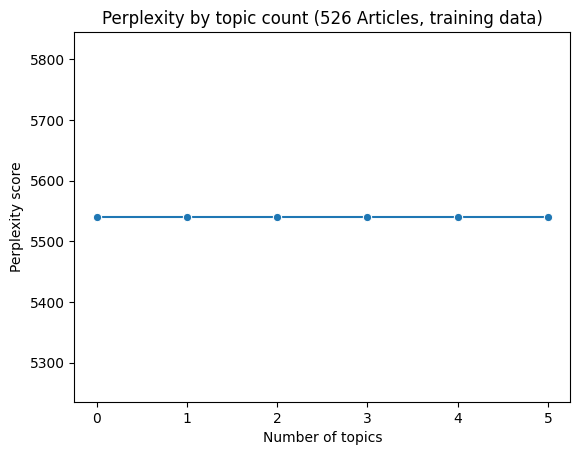

In [372]:
nArticles = X_train.shape[0]
plot_title = 'Perplexity by topic count (' + str(nArticles) + ' Articles, training data)'

# Plot perplexity by topic count
ax = sns.lineplot(x = topic_nums, y = perplexity_score, marker = 'o')
ax.set_title(plot_title)
ax.set_ylabel('Perplexity score'); ax.set_xlabel('Number of topics')
plt.show()

Good news / bad news
- Good news: the line is constant so the perplexity is consistent across all topics
- Bad news: The score is consistently very high across all topics. We kinda wanna bring that down, a bit.

In [373]:
# Save the model to a file
with open('Models/lda_model.pkl', 'wb') as file:
    pickle.dump(lda, file)

# Save the vectorizer to a file
with open('Models/lda_vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

# Topic Modeling with NMF
### Copy training dataset from LDA model and check distribution of word counts

In [374]:
X_train
X_train.shape[0]

526

In [375]:
datasetEDA = X_train.copy()

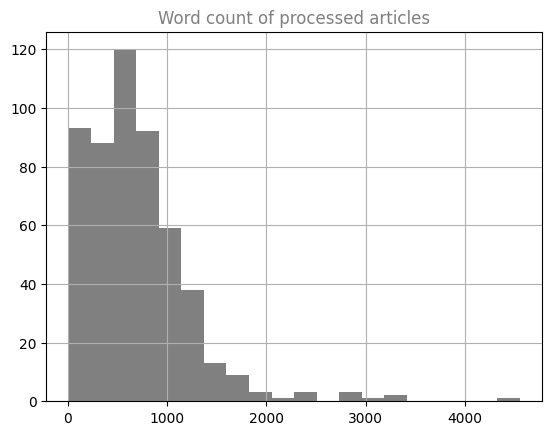

In [376]:
datasetEDA['word_count'] = X_train.apply(lambda x: len(str(x).split(' ')))
datasetEDA['word_count'].hist(bins=20,facecolor='grey')
plt.title("Word count of processed articles", alpha=0.5)
plt.show()

Articles are mainly short with a mode of about 700. The data skews all the way to ~4300 words for the largest articles.

### Vectorize the input data

In [377]:
TFIDFvectorizer = TfidfVectorizer(
    min_df = 5, #words must apear in at least 5 articles 
    max_df = 0.75, #words must apear in less then 75% of articles to ignore words that do not relate to specific topics
    max_features = 5000, #only keep top 5000 words
    ngram_range = (1, 2) #forces vectoriser to tokenize words individually and in pairs with their negbours
)

vectorized = TFIDFvectorizer.fit_transform(X_train)
vectorized

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 138231 stored elements and shape (526, 5000)>

Now we have made the first vector for NMF. It is 540 x 5000, or 5000 words for every one of the 540 articles we are using to train

### Train NMF

In [378]:
trained_nmf = NMF(
    n_components=5, #number of topics
    init='nndsvd' #initial values
).fit(vectorized)

nmf_output = trained_nmf.fit_transform(vectorized)

print("Input features:", vectorized.shape[1])
print("Expected features:", trained_nmf.components_.shape[1])

Input features: 5000
Expected features: 5000


Lets increase number of iterations to let the model converge

In [379]:
trained_nmf = NMF(
    n_components=5, #number of topics
    init='nndsvd', #initial values
    max_iter = 500 #max number of iterations allowed
).fit(vectorized)

nmf_output = trained_nmf.fit_transform(vectorized)

print("Input features:", vectorized.shape[1])
print("Expected features:", trained_nmf.components_.shape[1])

Input features: 5000
Expected features: 5000


In [380]:
# Print top 10 words for each topics

words = TFIDFvectorizer.get_feature_names_out() 

for topic_idx, topic in enumerate(trained_nmf.components_): 
    print(f"\nTopic #{topic_idx}:") 
    print([words[i] for i in topic.argsort()[:-10:-1]])


Topic #0:
['he', 'was', 'said', 'his', 'she', 'police', 'had', 'her', 'were']

Topic #1:
['said', 'its', 'new', 'are', 'global', 'percent', 'we', 'more', 'from']

Topic #2:
['season', 'you', 'we', 'rugby', 'game', 'league', 'final', 'be', 'his']

Topic #3:
['subscribe', 'herald', 'subscribe now', 'to listen', 'premium', 'listen', 'police', 'crash', 'herald may']

Topic #4:
['ship', 'hantavirus', 'the ship', 'passengers', 'cruise', 'health', 'outbreak', 'hondius', 'virus']


Here we can see the top tokens for our 5 categories, you can start to imagine what an article is about from these words.

### Testing different number of topics

In [381]:
error = {}

for i in range(2,21):
    nmf_model = NMF(n_components=i, init='nndsvd', max_iter = 500).fit(vectorized)
    error[i] = nmf_model.reconstruction_err_

error

{2: np.float64(21.927986481504764),
 3: np.float64(21.790218741924917),
 4: np.float64(21.64679885736702),
 5: np.float64(21.5141647451814),
 6: np.float64(21.38562929873899),
 7: np.float64(21.27724662489993),
 8: np.float64(21.177063744448713),
 9: np.float64(21.079536090544085),
 10: np.float64(20.989123281662426),
 11: np.float64(20.904662947983137),
 12: np.float64(20.817233475619823),
 13: np.float64(20.74377454419891),
 14: np.float64(20.65356249067038),
 15: np.float64(20.586409719335542),
 16: np.float64(20.500580250612675),
 17: np.float64(20.431970434866795),
 18: np.float64(20.358527263273217),
 19: np.float64(20.289175493319878),
 20: np.float64(20.220417124143406)}

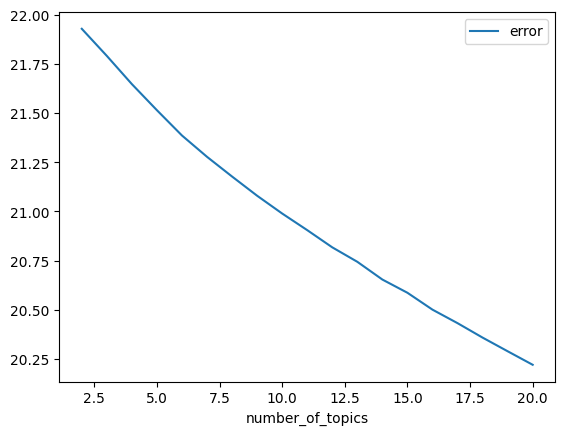

In [382]:
#plotting error data
error_df = pd.DataFrame(list(error.items()), columns = ["number_of_topics", "error"])

error_df.plot(x="number_of_topics", y="error")
plt.show()

The models show that the reconstruction error does improve as the number of topics increase but as the gradient is shallow there is no point to overfit the model. 5 Topics seems a good middle ground between overfitting yet still creating useful catergories.

In [383]:
# Save the model to a file
with open('Models/nmf_model.pkl', 'wb') as file:
    pickle.dump(trained_nmf, file)

# Save the vectorizer to a file
with open('Models/nmf_vectorizer.pkl', 'wb') as file:
    pickle.dump(TFIDFvectorizer, file)   

# Testing the models

In [384]:
# Load the LDA model and vectorizer from the file
with open('Models/lda_model.pkl', 'rb') as file:
    trained_lda = pickle.load(file)

with open('Models/lda_vectorizer.pkl', 'rb') as file:
    tLDA_vectorizer = pickle.load(file)

# Load the NMF model and Vectorizer from the file
with open('Models/nmf_model.pkl', 'rb') as file:
    trained_NMF = pickle.load(file)

with open('Models/nmf_vectorizer.pkl', 'rb') as file:
    tNMF_vectorizer = pickle.load(file)

Apply the trained models to new (test) data
1. Preprocess/vectorise the new data
2. Apply the pre-trained model

In [385]:
# LDA
tLDA_vectorized = tLDA_vectorizer.transform(X_test)
topic_distributions_LDA = trained_lda.transform(tLDA_vectorized)

# NMF
tNMF_vectorized = tNMF_vectorizer.transform(X_test)
topic_distributions_NMF = trained_NMF.transform(tNMF_vectorized)

In [386]:
print(f"LDA: {topic_distributions_LDA.shape}")
print(f"NMF: {topic_distributions_NMF.shape}")

LDA: (132, 5)
NMF: (132, 5)


Let's have a look at what the indices of our test articles are, and (manually) compare them to the dominant topics found by LDA and NMF.

In [387]:
test_index_values = X_test.index.values
dominant_topics_LDA = np.argmax(topic_distributions_LDA, axis=1)
dominant_topics_NMF = np.argmax(topic_distributions_NMF, axis=1)

In [388]:
test_topic_distribs_df = pd.DataFrame({'index':test_index_values,'LDA_Topic':dominant_topics_LDA,'NMF_Topic':dominant_topics_NMF})
test_topic_distribs_df

,index,LDA_Topic,NMF_Topic
0,875,0,0
1,75,0,0
2,1164,3,0
3,644,3,0
4,983,0,0
...,...,...,...
127,676,0,2
128,602,0,4
129,356,2,1
130,561,1,1


Let's see what kind of articles this is giving us and how reasonably they might be matching up on their 'topics'

In [389]:
curiouser = test_topic_distribs_df.loc[(test_topic_distribs_df['LDA_Topic'] == 3) & (test_topic_distribs_df['NMF_Topic'] == 1)]
curiouser

,index,LDA_Topic,NMF_Topic
7,425,3,1
9,180,3,1
16,802,3,1
31,334,3,1
55,969,3,1
88,379,3,1
118,215,3,1
124,1018,3,1


In [392]:
X_test[425]

'while letele and daniels correctly identified the original  host bridge did not  saying it was  quite hard  to spot the difference  similar reactions were observed from those attempting the hack  with some convinced the recipe had been cracked   this feels wrong  but the colour s right   said tokyo based new zealander xoe hashi  who put the trend to the test after seeing it online   i feel a little lied to because we grew up thinking it was lemon and paeroa  aka the spring water there   at pak nsave wairau rd  one worker urged kiwis to try it for themselves after being won over by their own attempt   it actually does taste like l p  not even joking   they said   that s so crazy  it tastes the exact same   a spokesperson for l p neither confirmed nor denied the hack s veracity  saying the recipe  has always been a closely held secret  since its beginnings in paeroa in the     s   what we can confirm is that it continues to be made to the same standards and delivers the same distinctive

In [393]:
X_test[180]

'photo     rf an economist is warning the unemployment rate is likely to get worse in the coming months and could reach up to   percent due to the iran war  and there is increasing concern for young people struggling to find work  the unemployment rate eased to     percent in the three months ended march  down slightly from the previous quarter  a total of         people were unemployed  a fall of      on the previous quarter but      higher than a year ago  kiwibank chief economist jarrod kerr said wednesday s data was  very outdated   and the full impact of the fuel crisis would be felt in the second or third quarter of this year  kiwibank was forecasting unemployment to reach     per cent  kerr said  but there was a chance it could reach     or   percent if conditions didn t improve  kiwibank chief economist jarrod kerr photo  supplied   gino demeer  we are hearing of  construction  projects being post poned  we are hearing of projects being cancelled  we are hearing of forestry cre

In [394]:
X_test[802]

'how much are first home buyers paying to get into the market now  by susan edmunds for rnz first home purchasers have been responsible for a large share of property transactions in recent years  and new research from cotality and westpac shows that continued through the start of this year  too  over the past year  first time buyers have purchased        properties   the highest annual number since the year to the third quarter of        whether you look at absolute numbers or relative share  it s all pretty positive   said cotality economist kelvin davidson  he said people were also getting more house for their money  more than     of purchases were of standalone houses  and the median price paid was            the median price so far has gone up to          from          last year but that s not a big increase  there s a rising share of standalone houses among first time buyer purchases  they re getting bang for their buck in a market that s titled in their favour with lots of listin

# Comparing performance of LDA vs NMF
First, we load in the trained models and their respective vectorizers - except, this time, we're applying them to the entire training dataset, initially (rather than splitting them up into train + test). We need to apply their topic labels to the entire set for the purposes of comparison.

In [395]:
comparison_df = news_training_df.copy()
news_content = comparison_df['Content']

# LDA
tLDA_vectorized = tLDA_vectorizer.transform(news_content)
topic_distributions_LDA = trained_lda.transform(tLDA_vectorized)

# NMF
tNMF_vectorized = tNMF_vectorizer.transform(news_content)
topic_distributions_NMF = trained_NMF.transform(tNMF_vectorized)

In [396]:
dominant_topics_LDA = np.argmax(topic_distributions_LDA, axis=1)
dominant_topics_NMF = np.argmax(topic_distributions_NMF, axis=1)

# Create a dictionary mapping topic indices to their primary keywords (or category names)
LDA_topic_mapping = {
    0: "Raspberry Jam",
    1: "Beef Jerkey",
    2: "Burpees",
    3: "High Jump",
    4: "Rainbows"
}

LDA_mapped_topics = [LDA_topic_mapping[int(topic)] for topic in dominant_topics_LDA]

comparison_df['LDA_DT_ID'] = dominant_topics_LDA
comparison_df['LDA_Topic'] = LDA_mapped_topics

# Same thing again but for NMF
NMF_topic_mapping = {
    0: "Groundhog Day",
    1: "Fish and Chips",
    2: "Hurdles",
    3: "Emergencies",
    4: "Dog breath"
}

NMF_mapped_topics = [NMF_topic_mapping[int(topic)] for topic in dominant_topics_NMF]

comparison_df['NMF_DT_ID'] = dominant_topics_NMF
comparison_df['NMF_Topic'] = NMF_mapped_topics

In [397]:
comparison_df.head(3)

,Unnamed: 0,Date,Source,Title,page_url,scraped_text,Content,LDA_DT_ID,LDA_Topic,NMF_DT_ID,NMF_Topic
0,1,2026-05-05 22:30:41,onenews_co_nz,New test for people applying for NZ citizenshi...,https://www.1news.co.nz/2026/05/06/new-test-fo...,The Government is set to introduce a new citiz...,the government is set to introduce a new citiz...,0,Raspberry Jam,1,Fish and Chips
1,2,2026-05-05 22:30:28,nzherald,Hylo: Rotorua school friends win at Australian...,https://www.nzherald.co.nz/rotorua-daily-post/...,More than 800 hairdressers and industry leader...,more than hairdressers and industry leader...,0,Raspberry Jam,0,Groundhog Day
2,3,2026-05-05 22:29:17,nzherald,Fifa World Cup: All Whites to play Haiti in Wo...,https://www.nzherald.co.nz/sport/football/foot...,"“Since the draw, we have been working to lock ...",since the draw we have been working to lock ...,4,Rainbows,2,Hurdles


## Using kNN for comparison

In [398]:
# Train, test, split - but with labels, this time
labels_LDA = comparison_df['LDA_Topic']
X_trainL, X_testL, y_trainL, y_testL = train_test_split(news_content, labels_LDA, test_size=0.2)

lda_vectorizer = CountVectorizer(stop_words=stop_words) # using the same parameters as before
tr_lda_matrix = lda_vectorizer.fit_transform(X_train)
te_lda_matrix = lda_vectorizer.transform(X_test)

lda = LatentDirichletAllocation(n_components=5, random_state=19) # using the same parameters as before
X_train_lda = lda.fit_transform(tr_lda_matrix)
X_test_lda = lda.transform(te_lda_matrix)

knn_lda = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn_lda.fit(X_train_lda, y_trainL)
lda_preds = knn_lda.predict(X_test_lda)

In [399]:
labels_NMF = comparison_df['NMF_Topic']
X_trainN, X_testN, y_trainN, y_testN = train_test_split(news_content, labels_NMF, test_size=0.2)

# NMF typically works best with TF-IDF, LDA uses raw word counts
nmf_vectorizer = TfidfVectorizer(max_df=0.75, min_df=5, max_features = 5000, ngram_range = (1, 2)) # using the same parameters as before
tr_nmf_matrix = nmf_vectorizer.fit_transform(X_train)
te_nmf_matrix = nmf_vectorizer.transform(X_test)

# 2. Extract Topics using NMF
nmf = NMF(n_components=5, init='nndsvd', max_iter = 500) # using the same parameters as before
X_train_nmf = nmf.fit_transform(tr_nmf_matrix)
X_test_nmf = nmf.transform(te_nmf_matrix)

# 4. Compare using KNeighborsClassifier
knn_nmf = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn_nmf.fit(X_train_nmf, y_trainN)
nmf_preds = knn_nmf.predict(X_test_nmf)

In [400]:
print("LDA + KNN Report:")
print(classification_report(y_testL, lda_preds))

print("NMF + KNN Report:")
print(classification_report(y_testN, nmf_preds))

LDA + KNN Report:
               precision    recall  f1-score   support

  Beef Jerkey       0.14      0.06      0.08        17
      Burpees       0.21      0.38      0.27        21
    High Jump       0.20      0.14      0.16        22
     Rainbows       0.29      0.14      0.19        29
Raspberry Jam       0.37      0.49      0.42        43

     accuracy                           0.28       132
    macro avg       0.24      0.24      0.22       132
 weighted avg       0.27      0.28      0.26       132

NMF + KNN Report:
                precision    recall  f1-score   support

    Dog breath       0.00      0.00      0.00         5
   Emergencies       0.00      0.00      0.00         1
Fish and Chips       0.42      0.69      0.53        59
 Groundhog Day       0.35      0.18      0.24        38
       Hurdles       0.12      0.03      0.05        29

      accuracy                           0.37       132
     macro avg       0.18      0.18      0.16       132
  weighted avg  

<strong>LDA:</strong>
The LDA model at least had some degree of precision with prediction across all topics (between 5% and 25%), and correctly recalled all topics at least some of the time (between 4% and 36%). These two factors are combined in the F-1 score, and reflect as much there.

Overall, it had an accuracy of just 18%.

<strong>NMF:</strong>
The NMF model had higher precision and recall for 3 out of 5 topics (between 21% and 40%, and 15% and 48%, respectively), but had difficulty with topics 1 and 4 in both aspects (which were at 0%). When looking at the Support column, this difficulty with those topics could be a reflection of the low number of articles those topics are related to.

Overall, this model an accuracy of just 32%.

<strong>Suggestions for model improvement:</strong> More training data could improve outcomes. As there aren't many articles in total, they are further reduced when split for testing and training, which does seem to impact the precision and accuracy of predicition and classification.

---
---

# Applying the LDA to new data

Consider this next bit the absolute 'work in progress' of all work-in-progresses. This isn't what it'll look like when it's done, this is just setting up the bones of it so we know (at least some of) what we're doing after the LDA

In [407]:
def frameify_NewsAPI_pickles(theseresults):
    training_df = pd.DataFrame(columns=['Date','Source','Title','Description','page_url'])
    results_list = []
    for i in theseresults:
        
        html_text = i['description'] or ''
        clean_text = re.sub(r'<.*?>', '', html_text)

        # Fix the date time format (the API has it as something like 2020-04-20T22:11:00)
        api_date = i['publishedAt']
        formatted_date = api_date.split('T')[0]

        new_row = {
            'Date': formatted_date, 
            'Source': i['source']['name'], 
            'Title':i['title'],
            'Description': clean_text.strip(),
            'page_url':i['url']
            }
        results_list.append(new_row)
    new_df = pd.DataFrame(results_list)
    training_df = pd.concat([training_df,new_df],axis=0)
    return training_df

def readNewsAPIPickles(thismany):
    newsPickleFiles = []
    numPickles = thismany
    newsPickles = []

    for i in range(numPickles):
        # appending the loop count to the filename so it adds the current number to the string
        # they all follow the same naming convention - I renamed a few to make sure of it
        filename = "Pickles/newsapi_geteverything" + str(i+1) + ".pkl" 
        newsPickleFiles.append(filename)

    for item in newsPickleFiles:
        with open(item, 'rb') as file:
            pickled = pickle.load(file)
            newsPickles.append(frameify_NewsAPI_pickles(pickled['articles']))
    
    return pd.concat(newsPickles,axis=0)   

In [409]:
bones_df = readNewsAPIPickles(2)
bones_df.reset_index(inplace=True)

bones_df.dtypes

index           int64
Date           object
Source         object
Title          object
Description    object
page_url       object
dtype: object

In [410]:
print(f"Columns: {bones_df.shape[1]}, Rows: {bones_df.shape[0]}")
print(f"NaNs: {bones_df.isna().any(axis=1).sum()}")
print(f"Full, exact duplicate matches: {bones_df.duplicated().sum()}")
print(f"Duplicated content: {bones_df['Description'].duplicated().sum()}")
print(f"Duplicated URLs: {bones_df['page_url'].duplicated().sum()}")

Columns: 6, Rows: 188
NaNs: 0
Full, exact duplicate matches: 0
Duplicated content: 4
Duplicated URLs: 0


In [411]:
# Preprocessing and lemmatizing
bones_df['Content'] = bones_df['Description'].apply(preprocess_text)
bones_df['Content'].astype(str).apply(lemmatize_tokenizer)

bones_content = bones_df['Content']

In [412]:
# Bring in the version of the LDA + vectorizer we're working with (for now)
# Trained OG vectorizer to transform new data
bones_matrix = vectorizer.transform(bones_content) 

# Trained OG LDA for the new vectorized data
bones_topics = trained_lda.transform(bones_matrix)

perplexity_score = []
topic_nums = range(6)

for topics in topic_nums:
    lda.fit(bones_matrix)
    perplexity_score.append(lda.perplexity(bones_matrix)) 

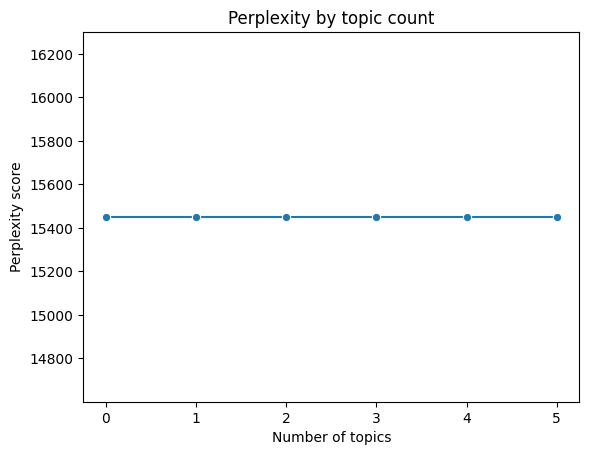

In [413]:
# Plot perplexity by topic count
ax = sns.lineplot(x = topic_nums, y = perplexity_score, marker = 'o')
ax.set_title('Perplexity by topic count')
ax.set_ylabel('Perplexity score'); ax.set_xlabel('Number of topics')
plt.show()

In [414]:
# Get the index of the topic with the highest probability for each document
dominant_topic_bones = np.argmax(bones_topics, axis=1)

# Create a DataFrame to view results clearly
df_dominant_topic_bones = pd.DataFrame({
    'Article_ID': range(len(dominant_topic_bones)),
    'Dominant_Topic': dominant_topic_bones,
    'Topic_Probability': np.max(bones_topics, axis=1)
})

df_dominant_topic_bones.head(1)

,Article_ID,Dominant_Topic,Topic_Probability
0,0,3,0.518704


In [415]:
# Patch the dominant topics in with the corresponding rows
bones_joined_df = pd.concat([bones_df,df_dominant_topic_bones], axis = 1)
bones_joined_df.head(1)

,index,Date,Source,Title,Description,page_url,Content,Article_ID,Dominant_Topic,Topic_Probability
0,0,2026-05-06,Gizmodo.com,Alaska’s Famous Fjords Are Becoming a Cruise S...,Climate change is making landslides and tsunam...,https://gizmodo.com/alaskas-famous-fjords-are-...,climate change is making landslides and tsunam...,0,3,0.518704


So, again - it is being a wee bit confused by the new data, but we can fix that with some better/more training data. The model is a work in progress.

# VADER

Let's apply some sentiment analysis to the news data

In [416]:
analyzer = SentimentIntensityAnalyzer()

# Apply sentiment analysis to each row
bones_joined_df['VADER_sentiment'] = bones_joined_df['Content'].apply(lambda x: analyzer.polarity_scores(x))

bones_joined_df.head(1)

,index,Date,Source,Title,Description,page_url,Content,Article_ID,Dominant_Topic,Topic_Probability,VADER_sentiment
0,0,2026-05-06,Gizmodo.com,Alaska’s Famous Fjords Are Becoming a Cruise S...,Climate change is making landslides and tsunam...,https://gizmodo.com/alaskas-famous-fjords-are-...,climate change is making landslides and tsunam...,0,3,0.518704,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."


In [417]:
# Expand VADER's output list into separate columns in its own mini frame
sentiment_expanded_df = pd.DataFrame(bones_joined_df['VADER_sentiment'].tolist(), index=bones_joined_df.index)
# rename the cols so they can be eyeballed easy later
sentiment_expanded_df.rename(columns={"neg":'vader_neg',"neu":"vader_neu","pos":'vader_pos',"compound":'vader_compound'}, inplace=True)
# Join the miniframe onto the big boi frame
bones_joined_df = pd.concat([bones_joined_df,sentiment_expanded_df],axis=1)

# Check that all worked
bones_joined_df.head(1)

,index,Date,Source,Title,Description,page_url,Content,Article_ID,Dominant_Topic,Topic_Probability,VADER_sentiment,vader_neg,vader_neu,vader_pos,vader_compound
0,0,2026-05-06,Gizmodo.com,Alaska’s Famous Fjords Are Becoming a Cruise S...,Climate change is making landslides and tsunam...,https://gizmodo.com/alaskas-famous-fjords-are-...,climate change is making landslides and tsunam...,0,3,0.518704,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.0


And then to check that's all working let's just do some visualisation of one topic over time

In [422]:
# Put it into something I can work into a timeseries
bones_topic3_df = bones_joined_df.loc[bones_joined_df['Dominant_Topic'] == 3]

# Group by 'Date' and then get the compound score (I guess?)
bones_topic3_dfvader = bones_topic3_df.groupby('Date').agg(Compound_score = ('vader_compound', 'mean'))
bones_topic3_dfvader.reset_index(inplace=True)
bones_topic3_dfvader.head(5)

,Date,Compound_score
0,2026-04-13,0.68130
1,2026-04-14,0.54230
2,2026-04-15,0.89175
3,2026-04-16,0.55740
4,2026-04-17,-0.10535


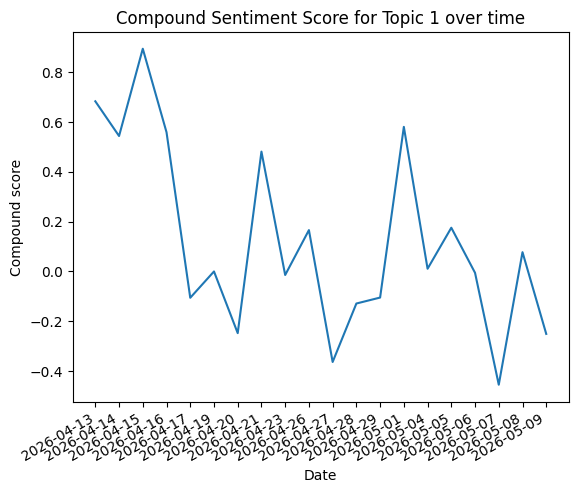

In [423]:
# Plotting the time series for Topic 3
plt.plot(bones_topic3_dfvader['Date'], bones_topic3_dfvader['Compound_score'])

# rotating the x-axis tick labels for readability
plt.xticks(rotation=30, ha='right')

# Add title
plt.title('Compound Sentiment Score for Topic 1 over time')

# Add appropriate x and y labels
plt.xlabel('Date')
plt.ylabel('Compound score')

plt.show()

In [424]:
from textblob import TextBlob

# Get sentiment score
def get_textblob_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply to dataset
bones_joined_df['textblob_polarity'] = bones_joined_df['Content'].apply(get_textblob_sentiment)

# Quick check
bones_joined_df[['vader_compound', 'textblob_polarity']].head()

,vader_compound,textblob_polarity
0,0.0000,0.166667
1,0.6682,0.267273
2,-0.0516,-0.100000
3,0.5574,-0.300000
4,-0.8417,-0.112500


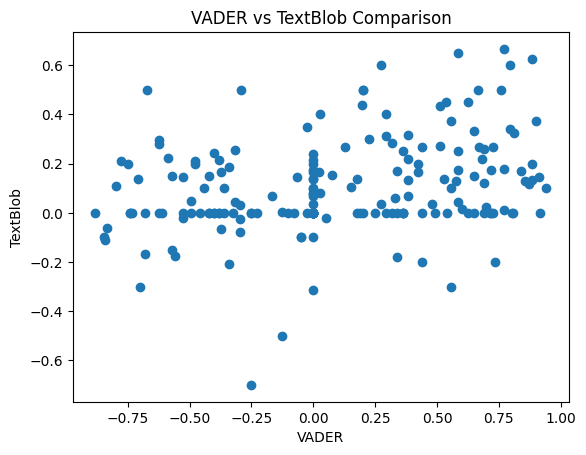

In [425]:
import matplotlib.pyplot as plt

plt.scatter(bones_joined_df['vader_compound'], bones_joined_df['textblob_polarity'])
plt.xlabel('VADER')
plt.ylabel('TextBlob')
plt.title('VADER vs TextBlob Comparison')
plt.show()

In [426]:
# Another timeseries
bones_topic3_df = bones_joined_df.loc[bones_joined_df['Dominant_Topic'] == 3]

# Group by 'Date' and then get the compound score (I guess?)
bones_topic3_dfvader_textblob = bones_topic3_df.groupby('Date').agg(Vader_compound = ('vader_compound', 'mean'), 
                                                                    TextBlob_Polarity = ('textblob_polarity', 'mean'))
bones_topic3_dfvader_textblob.reset_index(inplace=True)
bones_topic3_dfvader_textblob.head(5)

,Date,Vader_compound,TextBlob_Polarity
0,2026-04-13,0.68130,0.075000
1,2026-04-14,0.54230,0.000000
2,2026-04-15,0.89175,0.500000
3,2026-04-16,0.55740,0.375000
4,2026-04-17,-0.10535,0.074091


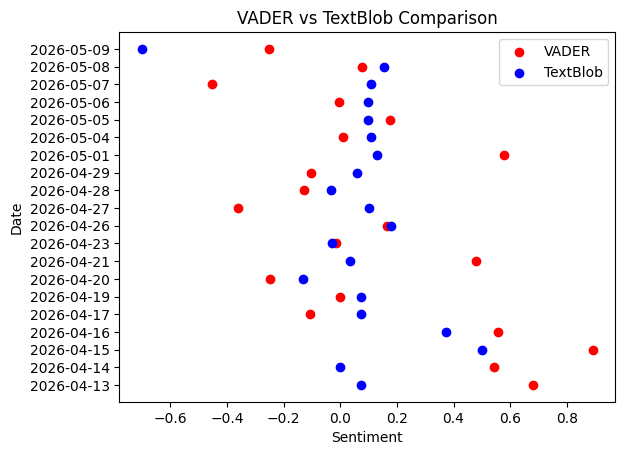

In [427]:
plt.scatter(bones_topic3_dfvader_textblob['Vader_compound'],bones_topic3_dfvader_textblob['Date'], color='red', label='VADER')
plt.scatter(bones_topic3_dfvader_textblob['TextBlob_Polarity'],bones_topic3_dfvader_textblob['Date'], color='blue', label='TextBlob')
plt.xlabel('Sentiment')
plt.ylabel('Date')
plt.title('VADER vs TextBlob Comparison')
plt.legend()
plt.show()